# Statistics of results on the whole dataset using (evalmaxsat vs exact)

In [39]:

!pwd

/Users/wilberquito/repos/mspsp-all/mspsp-stats/notebooks/smtapi


In [40]:
import os
import seaborn as sns
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional
from pathlib import Path
from pprint import pprint

ROOT = Path().resolve().parent.parent
DATA = ROOT / "data"
FIGURES = ROOT / "figures"

pipe = "smtapi"

DIRS = {
    "data": {
        "wandb": DATA / "wandb" / pipe,
        "analysis": DATA / "analysis" / pipe / "opb vs maxsat" / "exact vs evalmaxsat",
        "instances": DATA / "analysis" / pipe / "instances",
    },
    "figures": FIGURES / pipe,
}

pprint(DIRS)

{'data': {'analysis': PosixPath('/Users/wilberquito/repos/mspsp-all/mspsp-stats/data/analysis/smtapi/opb vs maxsat/exact vs evalmaxsat'),
          'instances': PosixPath('/Users/wilberquito/repos/mspsp-all/mspsp-stats/data/analysis/smtapi/instances'),
          'wandb': PosixPath('/Users/wilberquito/repos/mspsp-all/mspsp-stats/data/wandb/smtapi')},
 'figures': PosixPath('/Users/wilberquito/repos/mspsp-all/mspsp-stats/figures/smtapi')}


In [41]:
# Read all csv under the wandb directory
wandb_dir = DIRS["data"]["wandb"]

df_wandb = pd.concat(
    [
        pd.read_csv(os.path.join(wandb_dir, f))
        for f in os.listdir(wandb_dir)
        if f.endswith(".csv")
    ],
    ignore_index=True,
)
df_wandb.shape

(27408, 22)

In [42]:
df_wandb.columns

Index(['Unnamed: 0', 'name', 'formalism', 'implied_1', 'implied_2',
       'implied_3', 'implied_4', 'inline_config', 'mspsp_instance', 'solver',
       'solving_timeout_s', 'encoder.real_time', 'encoder.sys_time',
       'encoder.user_time', 'makespan', 'model', 'slurm.timeout',
       'solution_status', 'solver.real_time', 'solver.sys_time',
       'solver.user_time', 'pb_like'],
      dtype='object')

In [43]:
# Generate bitmask for implied
def add_implied_column(df: pd.DataFrame, check: bool) -> pd.DataFrame:
    # Creamos un ID único para la configuración de implied constraints

    impl_cols = [c for c in df.columns if "implied_" in c]
    df["implied_bitmask"] = df[impl_cols].apply(
        lambda x: "".join(["1" if val else "0" for val in x]), axis=1
    )

    if check:
        config_count = df["implied_bitmask"].value_counts()
        s = config_count.iloc[0]
        diff_n_count = 0
        logger: list[str] = list()

        for i, c in enumerate(config_count):
            if c != s:
                diff_n_count += 1
                logger.append(config_count.index[i])

        if diff_n_count > 0:
            print(
                f"WARNING: Configuration count mismatch: {diff_n_count} configurations have a different count than the first one"
            )
            print("Mismatched configurations:", logger)

    return df


def add_logarithmic_time(df: pd.DataFrame) -> pd.DataFrame:
    df["solver.log_real_time"] = df["solver.real_time"].apply(lambda x: np.log10(x))
    return df


def add_family(df: pd.DataFrame) -> pd.DataFrame:
    df["family"] = df["mspsp_instance"].map(lambda x: x.split("/")[-2])
    return df

In [44]:
df_wandb = add_implied_column(df_wandb, check=True)
df_wandb = add_logarithmic_time(df_wandb)
df_wandb = add_family(df_wandb)

df_wandb.columns

Index(['Unnamed: 0', 'name', 'formalism', 'implied_1', 'implied_2',
       'implied_3', 'implied_4', 'inline_config', 'mspsp_instance', 'solver',
       'solving_timeout_s', 'encoder.real_time', 'encoder.sys_time',
       'encoder.user_time', 'makespan', 'model', 'slurm.timeout',
       'solution_status', 'solver.real_time', 'solver.sys_time',
       'solver.user_time', 'pb_like', 'implied_bitmask',
       'solver.log_real_time', 'family'],
      dtype='object')

In [45]:
df_wandb.head(2)

,Unnamed: 0,name,formalism,implied_1,implied_2,implied_3,implied_4,inline_config,mspsp_instance,solver,...,model,slurm.timeout,solution_status,solver.real_time,solver.sys_time,solver.user_time,pb_like,implied_bitmask,solver.log_real_time,family
0,0,doctor-dukat-1,maxsat,0.0,1.0,0.0,0.0,"f=maxsat__s=evalmaxsat__i=i1=0,i2=1,i3=0,i4=0",./modules/rcpsp-instances/MSPSP/set-1a/inst_se...,evalmaxsat,...,v S_0:0; S_1:29; S_2:0; S_3:0; S_4:9; S_5:12; ...,False,OPTIMUM_FOUND,0.33,0.00,0.25,NaN,0100,-0.481486,set-1a
1,1,ensign-quark-2,maxsat,0.0,1.0,0.0,0.0,"f=maxsat__s=evalmaxsat__i=i1=0,i2=1,i3=0,i4=0",./modules/rcpsp-instances/MSPSP/set-1a/inst_se...,evalmaxsat,...,v S_0:0; S_1:10; S_2:0; S_3:0; S_4:10; S_5:28;...,False,OPTIMUM_FOUND,0.11,0.01,0.10,NaN,0100,-0.958607,set-1a


In [46]:
# Pick just solvers of interest
exclude_solvers = ["maxcdcl", "roundingsat"]
df_wandb = df_wandb[~df_wandb["solver"].isin(exclude_solvers)]

df_wandb.shape

(13704, 25)

In [47]:
# Exclude implied conf

exclude_bitmasks = ["0001"]
df_wandb = df_wandb[~df_wandb["implied_bitmask"].isin(exclude_bitmasks)]

df_wandb.shape

(11420, 25)

In [48]:
df_wandb["inline_config"].value_counts().sort_index()

inline_config
f=maxsat__s=evalmaxsat__i=i1=0,i2=0,i3=0,i4=0         1142
f=maxsat__s=evalmaxsat__i=i1=0,i2=0,i3=1,i4=0         1142
f=maxsat__s=evalmaxsat__i=i1=0,i2=1,i3=0,i4=0         1142
f=maxsat__s=evalmaxsat__i=i1=1,i2=0,i3=0,i4=0         1142
f=maxsat__s=evalmaxsat__i=i1=1,i2=1,i3=0,i4=0         1142
f=opb__s=exactpb__i=i1=0,i2=0,i3=0,i4=0__pb_like=0    1142
f=opb__s=exactpb__i=i1=0,i2=0,i3=1,i4=0__pb_like=0    1142
f=opb__s=exactpb__i=i1=0,i2=1,i3=0,i4=0__pb_like=0    1142
f=opb__s=exactpb__i=i1=1,i2=0,i3=0,i4=0__pb_like=0    1142
f=opb__s=exactpb__i=i1=1,i2=1,i3=0,i4=0__pb_like=0    1142
Name: count, dtype: int64

In [49]:
df_wandb["implied_bitmask"].value_counts()

implied_bitmask
0100    2284
1000    2284
0010    2284
0000    2284
1100    2284
Name: count, dtype: int64

In [50]:
# Mapping of implied_bitmask

shorten_implied_mapping = {
    "0000": "000",
    "1000": "100",
    "0100": "010",
    "0010": "001",
    "1100": "110",
}

implied_mapping = {
    "0000": "No implied constraints",
    "1000": "Implied constraints 1",
    "0100": "Implied constraints 2",
    "0010": "Implied constraints 3",
    "1100": "Implied constraints 1 and 2",
    "0001": "Implied constraints 4",
}

implied_order = {
    "0000": 0,
    "000": 0,
    "1000": 1,
    "100": 1,
    "0100": 2,
    "010": 2,
    "1100": 3,
    "110": 3,
    "0010": 4,
    "001": 4,
    "0001": 5,
}

df_wandb["implied_bitmask_short"] = df_wandb["implied_bitmask"].map(
    shorten_implied_mapping
)
df_wandb["implied_bitmask_description"] = df_wandb["implied_bitmask"].map(
    implied_mapping
)
df_wandb["implied_bitmask_order"] = df_wandb["implied_bitmask"].map(implied_order)

df_wandb.shape

(11420, 28)

In [51]:
df_wandb[
    [
        "implied_bitmask",
        "implied_bitmask_short",
        "implied_bitmask_description",
        "implied_bitmask_order",
    ]
].drop_duplicates().sort_values("implied_bitmask_order").reset_index(drop=True)

,implied_bitmask,implied_bitmask_short,implied_bitmask_description,implied_bitmask_order
0,0000,000,No implied constraints,0
1,1000,100,Implied constraints 1,1
2,0100,010,Implied constraints 2,2
3,1100,110,Implied constraints 1 and 2,3
4,0010,001,Implied constraints 3,4


In [52]:
df_wandb["solver.real_time"].describe()

count    11420.000000
mean       307.548391
std        290.992875
min          0.020000
25%          1.050000
50%        326.315000
75%        600.000000
max        600.030000
Name: solver.real_time, dtype: float64

In [53]:
df_wandb["solver.log_real_time"].describe()

count    11420.000000
mean         1.437370
std          1.550130
min         -1.698970
25%          0.021189
50%          2.513625
75%          2.778151
max          2.778173
Name: solver.log_real_time, dtype: float64

In [54]:
df_wandb["solver"].value_counts()

solver
evalmaxsat    5710
exactpb       5710
Name: count, dtype: int64

In [55]:
# Rename the exact pseudo boolean solver from exactpb to exact

df_wandb["solver"] = df_wandb["solver"].replace({"exactpb": "exact"})
df_wandb["solver"].value_counts()

solver
evalmaxsat    5710
exact         5710
Name: count, dtype: int64

In [56]:
df_wandb.groupby(["solver", "implied_bitmask_short"])["solution_status"].value_counts()

solver      implied_bitmask_short  solution_status
evalmaxsat  000                    UNKNOWN            616
                                   OPTIMUM_FOUND      526
            001                    OPTIMUM_FOUND      719
                                   UNKNOWN            423
            010                    OPTIMUM_FOUND      684
                                   UNKNOWN            458
            100                    UNKNOWN            613
                                   OPTIMUM_FOUND      529
            110                    OPTIMUM_FOUND      694
                                   UNKNOWN            448
exact       000                    SATISFIABLE        616
                                   OPTIMUM_FOUND      464
                                   UNKNOWN             62
            001                    OPTIMUM_FOUND      619
                                   SATISFIABLE        520
                                   UNKNOWN              3
            010      

In [57]:
df_wandb["timeout"] = df_wandb["solution_status"] != "OPTIMUM_FOUND"

timeout_df = df_wandb.groupby(["solver", "implied_bitmask_short"])[
    "timeout"
].value_counts()
timeout_df

solver      implied_bitmask_short  timeout
evalmaxsat  000                    True       616
                                   False      526
            001                    False      719
                                   True       423
            010                    False      684
                                   True       458
            100                    True       613
                                   False      529
            110                    False      694
                                   True       448
exact       000                    True       678
                                   False      464
            001                    False      619
                                   True       523
            010                    False      583
                                   True       559
            100                    True       671
                                   False      471
            110                    False      592
       

In [58]:
xs = list()
for solver in df_wandb["solver"].unique():
    implied_bitmasks = (
        timeout_df[solver].index.get_level_values("implied_bitmask_short").unique()
    )
    for implied_bitmask in implied_bitmasks:
        timeout = (
            timeout_df[solver].loc[implied_bitmask, True]
            if (implied_bitmask, True) in timeout_df[solver].index
            else 0
        )
        data = {
            "solver": solver,
            "implied_bitmask": implied_bitmask,
            "timeout": timeout,
        }
        xs.append(data)

pd.DataFrame(xs)

,solver,implied_bitmask,timeout
0,evalmaxsat,000,616
1,evalmaxsat,001,423
2,evalmaxsat,010,458
3,evalmaxsat,100,613
4,evalmaxsat,110,448
5,exact,000,678
6,exact,001,523
7,exact,010,559
8,exact,100,671
9,exact,110,550


In [59]:
import pandas as pd

# 1. Define the custom order for the bitmasks
implied_order = {"000": 0, "100": 1, "010": 2, "110": 3, "001": 4}

# 2. Calculate Mean, Median, and Standard Deviation (std) per solver and mask
df_summary = (
    df_wandb.groupby(["solver", "implied_bitmask_short"])["solver.real_time"]
    .agg(["median"])
    .reset_index()
)


# 3. Calculate boosting for Mean and Median only (Standard Deviation remains raw)
def calculate_boosting(group):
    baseline_row = group[group["implied_bitmask_short"] == "000"]

    if not baseline_row.empty:
        base_med = baseline_row["median"].values[0]

        group["boost med %"] = ((base_med - group["median"]) / base_med) * 100
    else:
        group["boost med %"] = 0.0
    return group


df_summary = df_summary.groupby("solver", group_keys=False).apply(calculate_boosting)

# 4. Pivot the table
df_final = df_summary.pivot(
    index="implied_bitmask_short",
    columns="solver",
    values=["median", "boost med %"],
)

# 5. Map metrics to friendly column names
name_map = {
    "median": "med.",
    "boost med %": "boost med. %",
}

# Flatten MultiIndex columns: "Solver Metric"
df_final.columns = [
    f"{solver} {name_map[metric]}" for metric, solver in df_final.columns
]

# 6. Sort by custom order and round results
df_final = df_final.sort_index(key=lambda x: x.map(implied_order)).round(2)

# Save to CSV
df_final.to_csv(DIRS["data"]["analysis"] / "boosting_summary_median.csv")

df_final

/var/folders/pg/qxgft6y5619fnqtqh5mq_lx00000gn/T/ipykernel_13933/2617633840.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_summary = df_summary.groupby("solver", group_keys=False).apply(calculate_boosting)


,evalmaxsat med.,exact med.,evalmaxsat boost med. %,exact boost med. %
implied_bitmask_short,,,,
000,600.00,600.00,0.00,0.00
100,600.00,600.00,0.00,0.00
010,32.44,341.04,94.59,43.16
110,31.38,232.81,94.77,61.20
001,37.10,120.12,93.82,79.98


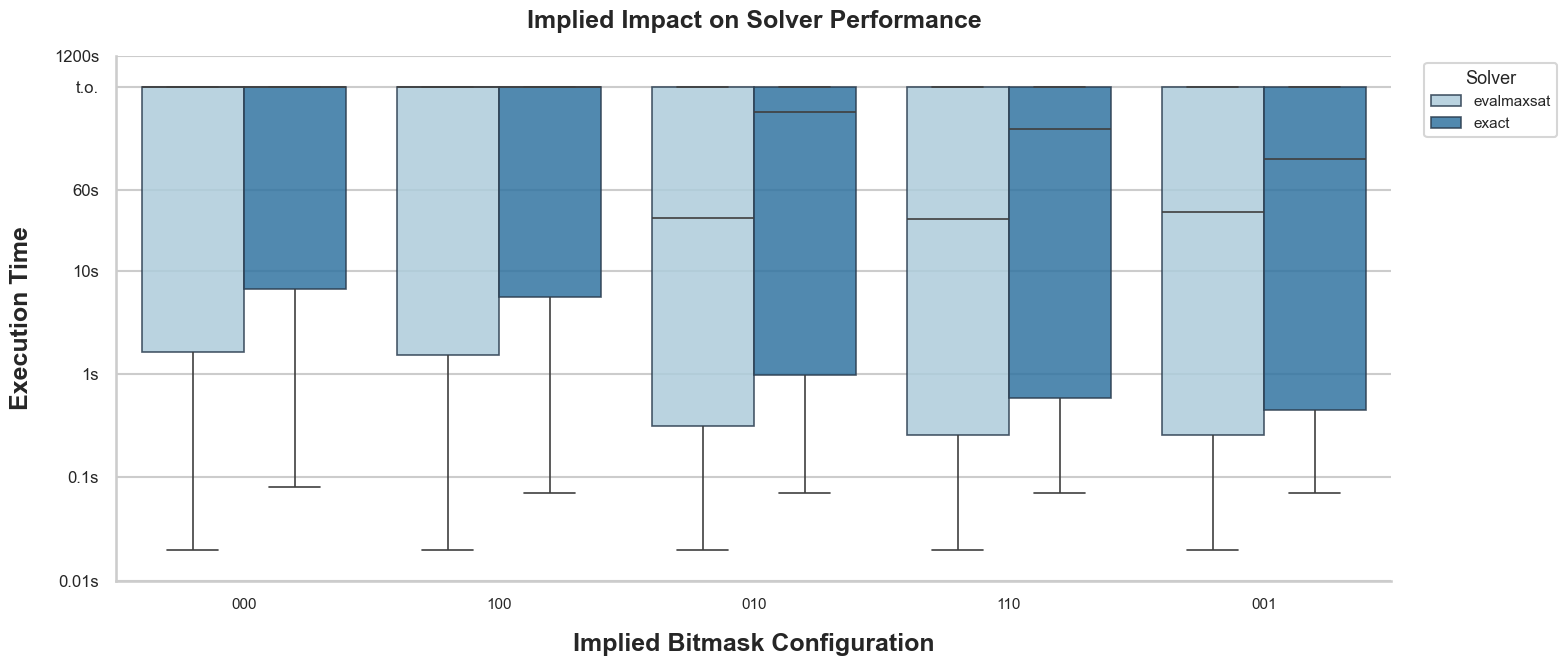

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- Setup and Styling ---
sns.set_theme(style="whitegrid", context="talk")
sns.set_palette("Paired")

# Create a copy for manipulation
show_df = df_wandb.copy()
show_df["implied_bitmask_str"] = show_df["implied_bitmask_short"].astype(str)

# --- Define Plotting Order ---
implied_order = [
    "000",
    "100",
    "010",
    "110",
    "001",
    #  "0001",
]

solver_order = sorted(show_df["solver"].unique().tolist())

# --- Initialize Plot ---
plt.figure(figsize=(16, 7))

# The key fix: x is now the bitmask, hue is the solver
ax = sns.boxplot(
    data=show_df,
    x="implied_bitmask_str",
    y="solver.log_real_time",
    hue="solver",
    order=implied_order,  # Groups on the X-axis
    hue_order=solver_order,  # Colors within each group
    linewidth=1.2,
    fliersize=1,
    width=0.8,
    boxprops={"alpha": 0.85, "edgecolor": "#2c3e50"},
)

# --- Y-Axis Log Scale and Human-Readable Labels ---
timeout_log = np.log10(600)
human_times = [0.01, 0.1, 1, 10, 60, 600, 1200]

ymin, ymax = ax.get_ylim()
ymax = max(ymax, timeout_log + 0.2)  # Ensure the timeout line is visible
ax.set_ylim(ymin, ymax)

ticks = []
labels = []
for t in human_times:
    log_t = np.log10(t)
    ticks.append(log_t)
    labels.append(f"{t}s" if t != 600 else "t.o.")

ax.set_yticks(ticks)
ax.set_yticklabels(labels, fontsize=12)

# --- Labels and Aesthetics ---
ax.set_xlabel("Implied Bitmask Configuration", labelpad=15, weight="bold")
ax.set_ylabel("Execution Time", labelpad=15, weight="bold")
ax.set_title("Implied Impact on Solver Performance", pad=20, weight="bold", fontsize=18)

plt.xticks(rotation=0, fontsize=11)
sns.despine(trim=False)

# --- Legend ---
plt.legend(
    title="Solver",
    title_fontsize=13,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
    fontsize=11,
)

plt.tight_layout()
plt.show()

In [61]:
instances_description_csv = f"{DIRS['data']['instances']}/mspsp_stats.csv"
instances_description_df = pd.read_csv(instances_description_csv)
instances_description_df.shape

(1142, 10)

In [62]:
df_wandb.shape

(11420, 29)

In [63]:
len(df_wandb["implied_bitmask"].unique()) * len(df_wandb["solver"].unique())

10

In [64]:
# Outer group

instances_description_df["group"] = instances_description_df["family"].map(
    lambda x: x[:-1]
)
instances_description_df["group"].value_counts()

group
set-1    432
set-3    432
set-2    278
Name: count, dtype: int64

In [65]:
df_wandb = df_wandb.merge(
    instances_description_df[
        ["mspsp_instance", "modified_resource_strength", "group", "family"]
    ],
    on="mspsp_instance",
)

df_wandb.shape

(11420, 32)

In [66]:
df_wandb.columns

Index(['Unnamed: 0', 'name', 'formalism', 'implied_1', 'implied_2',
       'implied_3', 'implied_4', 'inline_config', 'mspsp_instance', 'solver',
       'solving_timeout_s', 'encoder.real_time', 'encoder.sys_time',
       'encoder.user_time', 'makespan', 'model', 'slurm.timeout',
       'solution_status', 'solver.real_time', 'solver.sys_time',
       'solver.user_time', 'pb_like', 'implied_bitmask',
       'solver.log_real_time', 'family_x', 'implied_bitmask_short',
       'implied_bitmask_description', 'implied_bitmask_order', 'timeout',
       'modified_resource_strength', 'group', 'family_y'],
      dtype='object')

In [67]:
df_wandb = df_wandb.drop(columns=["family_y"], axis=1)
df_wandb = df_wandb.rename(columns={"family_x": "family"})
df_wandb.head(2)

,Unnamed: 0,name,formalism,implied_1,implied_2,implied_3,implied_4,inline_config,mspsp_instance,solver,...,pb_like,implied_bitmask,solver.log_real_time,family,implied_bitmask_short,implied_bitmask_description,implied_bitmask_order,timeout,modified_resource_strength,group
0,0,doctor-dukat-1,maxsat,0.0,1.0,0.0,0.0,"f=maxsat__s=evalmaxsat__i=i1=0,i2=1,i3=0,i4=0",./modules/rcpsp-instances/MSPSP/set-1a/inst_se...,evalmaxsat,...,NaN,0100,-0.481486,set-1a,010,Implied constraints 2,2,False,0.125,set-1
1,1,ensign-quark-2,maxsat,0.0,1.0,0.0,0.0,"f=maxsat__s=evalmaxsat__i=i1=0,i2=1,i3=0,i4=0",./modules/rcpsp-instances/MSPSP/set-1a/inst_se...,evalmaxsat,...,NaN,0100,-0.958607,set-1a,010,Implied constraints 2,2,False,0.125,set-1


In [68]:
families = df_wandb[["group", "family"]].drop_duplicates()
stats = list()

for _, row in families.iterrows():
    f = row["family"]
    g = row["group"]
    f_df = df_wandb[df_wandb["family"] == f]
    col = f_df["modified_resource_strength"]
    data = {
        "group": g,
        "family": f,
        "min": col.min(),
        "max": col.max(),
        "mean": col.mean(),
        "std": col.std(),
        "q25": col.quantile(0.25),
        "median": col.median(),
        "q75": col.quantile(0.75),
        "iqr": col.quantile(0.75) - col.quantile(0.25),
        "n": col.count(),
    }
    stats.append(data)

mrs_df = pd.DataFrame(stats)
mrs_df = mrs_df.round(4)

# Rename columns
columns = [f"mrs_{col}" for col in mrs_df.columns if col not in ["group", "family"]]

mrs_df.columns = ["group", "family"] + columns

mrs_df.sort_values(["group", "mrs_mean"], ascending=[True, False])

,group,family,mrs_min,mrs_max,mrs_mean,mrs_std,mrs_q25,mrs_median,mrs_q75,mrs_iqr,mrs_n
0,set-1,set-1a,0.0758,0.2273,0.1548,0.0414,0.1250,0.1625,0.1875,0.0625,2160
1,set-1,set-1b,0.0591,0.1032,0.0783,0.0128,0.0625,0.0781,0.0938,0.0312,2160
2,set-2,set-2a,0.0135,0.1652,0.0673,0.0330,0.0500,0.0533,0.0847,0.0347,1100
4,set-2,set-2c,0.0212,0.1786,0.0561,0.0304,0.0296,0.0488,0.0755,0.0458,910
3,set-2,set-2b,0.0108,0.0798,0.0366,0.0244,0.0160,0.0180,0.0619,0.0458,770
6,set-3,set-3b,0.0208,0.0625,0.0370,0.0114,0.0278,0.0352,0.0417,0.0139,2160
5,set-3,set-3a,0.0117,0.0352,0.0209,0.0064,0.0156,0.0198,0.0234,0.0078,2160


In [69]:
mrs_df.columns

Index(['group', 'family', 'mrs_min', 'mrs_max', 'mrs_mean', 'mrs_std',
       'mrs_q25', 'mrs_median', 'mrs_q75', 'mrs_iqr', 'mrs_n'],
      dtype='object')

In [70]:
df_wandb.columns

Index(['Unnamed: 0', 'name', 'formalism', 'implied_1', 'implied_2',
       'implied_3', 'implied_4', 'inline_config', 'mspsp_instance', 'solver',
       'solving_timeout_s', 'encoder.real_time', 'encoder.sys_time',
       'encoder.user_time', 'makespan', 'model', 'slurm.timeout',
       'solution_status', 'solver.real_time', 'solver.sys_time',
       'solver.user_time', 'pb_like', 'implied_bitmask',
       'solver.log_real_time', 'family', 'implied_bitmask_short',
       'implied_bitmask_description', 'implied_bitmask_order', 'timeout',
       'modified_resource_strength', 'group'],
      dtype='object')

In [71]:
df_wandb = df_wandb.merge(
    mrs_df[["family", "mrs_mean", "mrs_std"]],
    on="family",
)
df_wandb.shape

(11420, 33)

In [72]:
df_wandb.columns

Index(['Unnamed: 0', 'name', 'formalism', 'implied_1', 'implied_2',
       'implied_3', 'implied_4', 'inline_config', 'mspsp_instance', 'solver',
       'solving_timeout_s', 'encoder.real_time', 'encoder.sys_time',
       'encoder.user_time', 'makespan', 'model', 'slurm.timeout',
       'solution_status', 'solver.real_time', 'solver.sys_time',
       'solver.user_time', 'pb_like', 'implied_bitmask',
       'solver.log_real_time', 'family', 'implied_bitmask_short',
       'implied_bitmask_description', 'implied_bitmask_order', 'timeout',
       'modified_resource_strength', 'group', 'mrs_mean', 'mrs_std'],
      dtype='object')

In [73]:
family_order = (
    df_wandb.groupby(["family"])["mrs_mean"]
    .mean()
    .reset_index()
    .sort_values(["family"], ascending=[True])["family"]
    .tolist()
)

family_order

['set-1a', 'set-1b', 'set-2a', 'set-2b', 'set-2c', 'set-3a', 'set-3b']

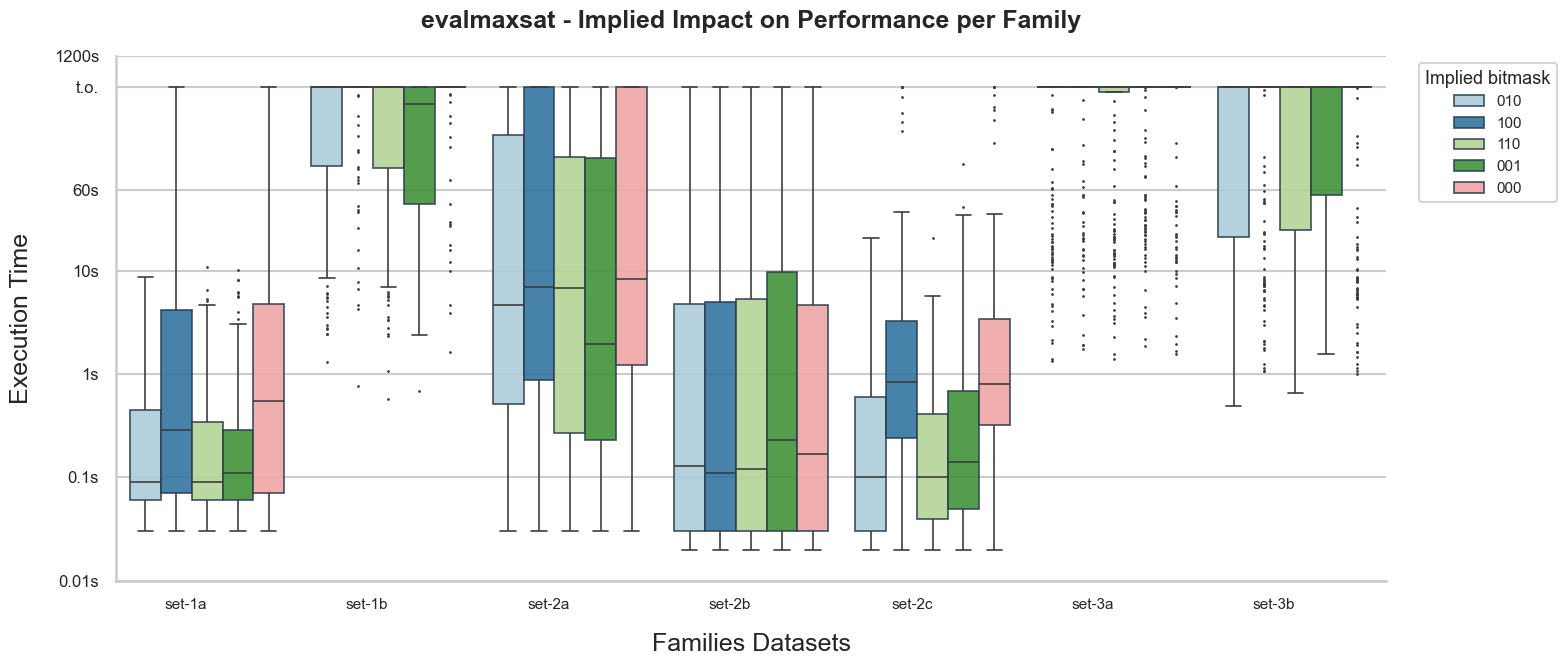

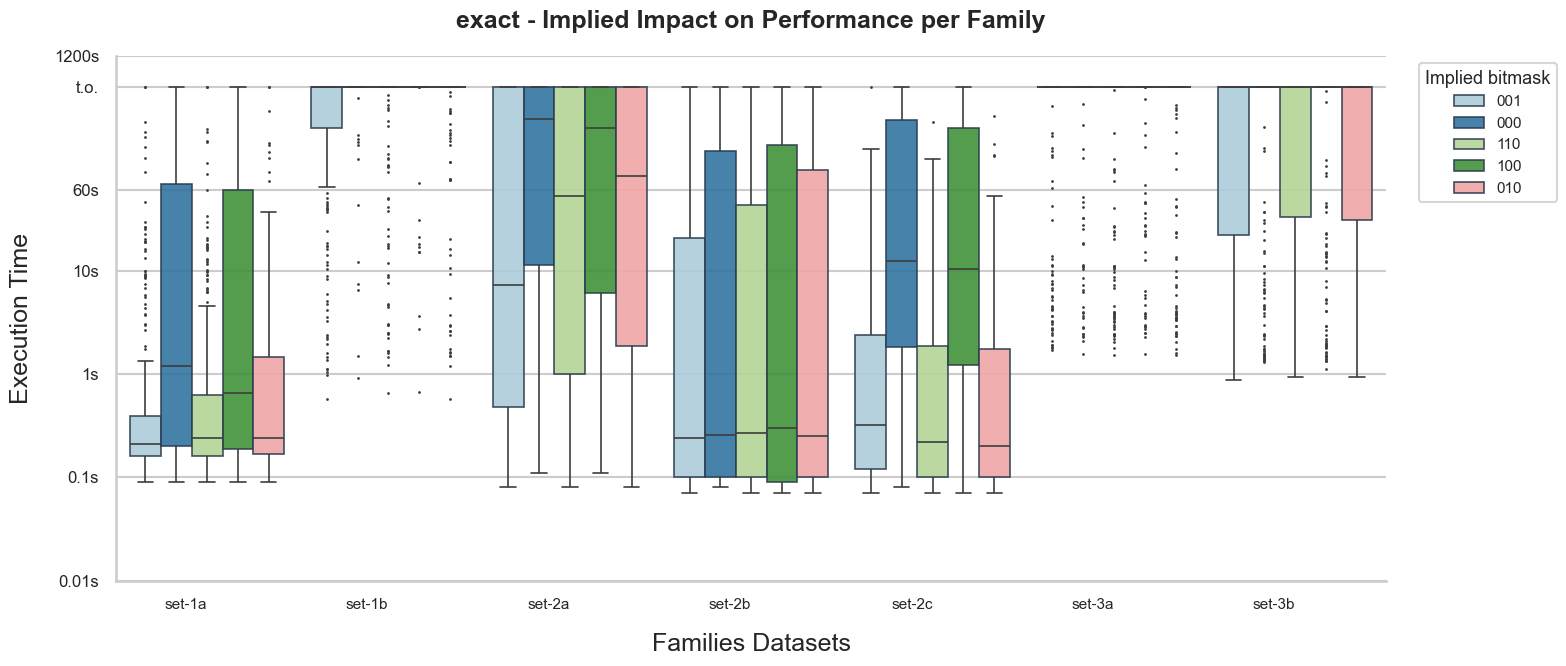

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="whitegrid", context="talk")
sns.set_palette("Paired")


show_df = df_wandb.copy()


show_df["implied_bitmask_str"] = show_df["implied_bitmask_short"].astype(str)

implied_order = [
    "000",
    "100",
    "010",
    "110",
    "001",
    # "0001",
]

solver_order = show_df["solver"].unique().tolist()

for solver in solver_order:

    #  group_order = [imp for imp in implied_order]

    # Increased width to 16 to handle the dense grouping per bin
    plt.figure(figsize=(16, 7))

    data_df = show_df[show_df["solver"] == solver]

    # Add padding and label for better aesthetics
    ax = sns.boxplot(
        data=data_df,
        x="family",
        y="solver.log_real_time",
        hue="implied_bitmask_str",
        #  hue_order=group_order,
        order=family_order,
        linewidth=1.2,
        fliersize=1,
        width=0.85,  # Slightly wider to utilize space
        boxprops={"alpha": 0.9, "edgecolor": "#2c3e50"},
    )

    timeout_log = np.log10(600)
    human_times = [0.01, 0.1, 1, 10, 60, 600, 1200]

    ymin, ymax = ax.get_ylim()
    ymax = max(ymax, timeout_log + 0.2)  # Ensure 600s is visible
    ax.set_ylim(ymin, ymax)

    ticks, labels = [], []
    for t in human_times:
        log_t = np.log10(t)
        ticks.append(log_t)
        labels.append(f"{t}s" if t != 600 else "t.o.")

    ax.set_yticks(ticks)
    ax.set_yticklabels(labels, fontsize=12)

    #    # Modify xticks labels by adding the mrs range for each family
    #    ticks = ax.get_xticks()
    #    xticklabels = ax.get_xticklabels()
    #    xticklabels = [
    #        f"{xt.get_text()} \n {data_df.loc[data_df['family'] == xt.get_text(), 'mrs_mean'].iloc[0]:.3f} ± {data_df.loc[data_df['family'] == xt.get_text(), 'mrs_std'].iloc[0]:.3f}"
    #        for xt in xticklabels
    #    ]
    #    ax.set_xticks(ticks)
    #    ax.set_xticklabels(xticklabels, rotation=0, ha="center", fontsize=11)
    #
    ax.set_xlabel("Families Datasets", labelpad=15)
    ax.set_ylabel("Execution Time", labelpad=15)
    ax.set_title(
        f"{solver} - Implied Impact on Performance per Family",
        pad=20,
        weight="bold",
    )

    plt.xticks(rotation=0, ha="right", fontsize=11)

    sns.despine(trim=False)

    plt.legend(
        title="Implied bitmask",
        title_fontsize=13,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=True,
        fontsize=11,
    )

    plt.tight_layout()
    plt.show()

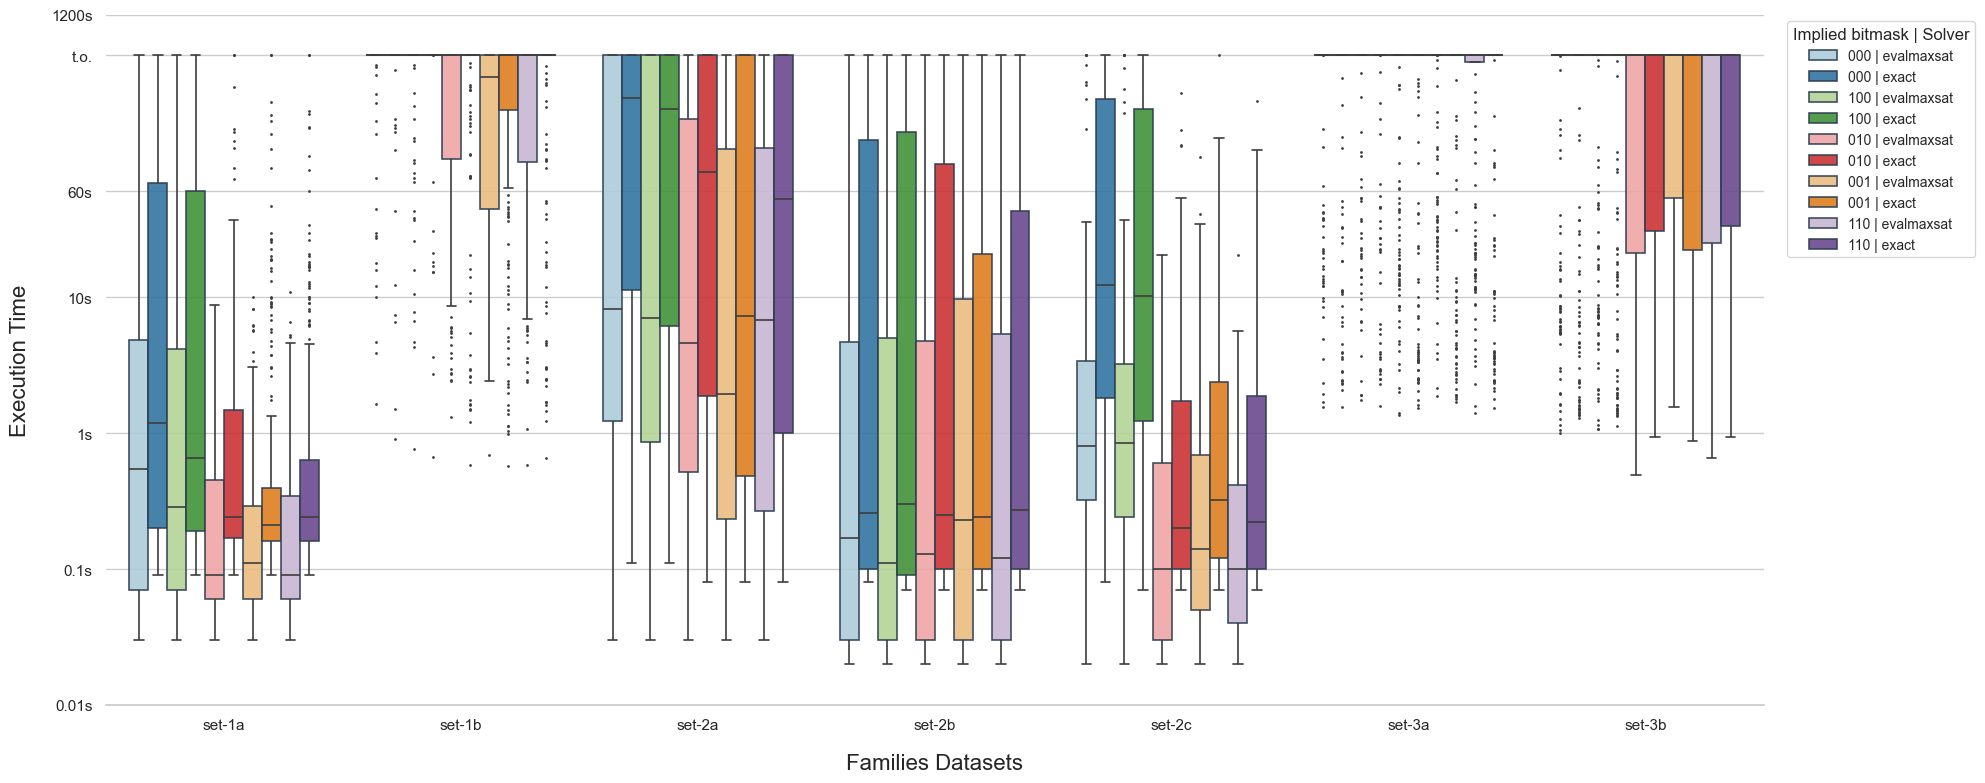

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Data Cleaning ---
show_df = df_wandb.copy()

# IMPORTANT: Check if your bitmasks are '000' or '0000' in the data!
# Based on your image, it looks like 4 digits.
implied_order = ["000", "100", "010", "001", "110"]
solvers_to_compare = ["evalmaxsat", "exact"]

# Standardize the columns to avoid mismatches
show_df["implied_bitmask_str"] = show_df["implied_bitmask_short"].astype(str)
show_df["solver"] = show_df["solver"].astype(str).str.strip()

# Create the specific combined column
show_df["hue_group"] = show_df["implied_bitmask_str"] + " | " + show_df["solver"]

# Filter data to ONLY include the solvers we are comparing
plot_df = show_df[show_df["solver"].isin(solvers_to_compare)].copy()

# --- 2. Construct Hue Order ---
group_order = []
for imp in implied_order:
    for sol in solvers_to_compare:
        group_order.append(f"{imp} | {sol}")

# --- DEBUG: Run this if you still get the error ---
# This checks if there is a mismatch between your order and your data
existing_groups = plot_df["hue_group"].unique()
missing = [g for g in group_order if g not in existing_groups]
if missing:
    print(f"Warning: These groups are in your order but NOT in your data: {missing}")
# --------------------------------------------------

# --- 3. Plotting ---
plt.figure(figsize=(20, 8))
sns.set_theme(style="whitegrid")

# We need 2 colors per bitmask (Total 12 colors for 6 bitmasks)
# Paired palette: [Light Blue, Dark Blue, Light Green, Dark Green, etc.]
palette = sns.color_palette("Paired", len(group_order))

ax = sns.boxplot(
    data=plot_df,
    x="family",
    y="solver.log_real_time",
    hue="hue_group",
    hue_order=group_order,
    order=family_order,
    palette=palette,
    linewidth=1.2,
    fliersize=1,
    width=0.8,
    boxprops={"alpha": 0.9, "edgecolor": "#2c3e50"},
)

# --- 4. Axes & Labels ---
timeout_log = np.log10(600)
human_times = [0.01, 0.1, 1, 10, 60, 600, 1200]
ax.set_ylim(plot_df["solver.log_real_time"].min() - 0.2, timeout_log + 0.3)

ax.set_yticks([np.log10(t) for t in human_times])
ax.set_yticklabels(
    [f"{t}s" if t < 600 else ("t.o." if t == 600 else "1200s") for t in human_times]
)

# # Formatting X-axis with MRS stats
# new_xticklabels = []
# for xt in ax.get_xticklabels():
#     fam = xt.get_text()
#     fam_data = plot_df[plot_df["family"] == fam]
#     if not fam_data.empty:
#         m_mean = fam_data["mrs_mean"].iloc[0]
#         m_std = fam_data["mrs_std"].iloc[0]
#         new_xticklabels.append(f"{fam}\n{m_mean:.3f} ± {m_std:.3f}")
#     else:
#         new_xticklabels.append(fam)
#
# ax.set_xticklabels(new_xticklabels, rotation=0, ha="center", fontsize=11)

# --- 5. Aesthetics & Legend ---
# ax.set_title(
#     "evalmaxsat vs. exact - Implied Impact on Performance per Dataset Family",
#     fontsize=18,
#     weight="bold",
#     pad=20,
# )
ax.set_xlabel("Families Datasets", fontsize=16, labelpad=15)
ax.set_ylabel("Execution Time", fontsize=16, labelpad=15)

plt.legend(
    title="Implied bitmask | Solver",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    frameon=True,
    fontsize=10,
    title_fontsize=12,
)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

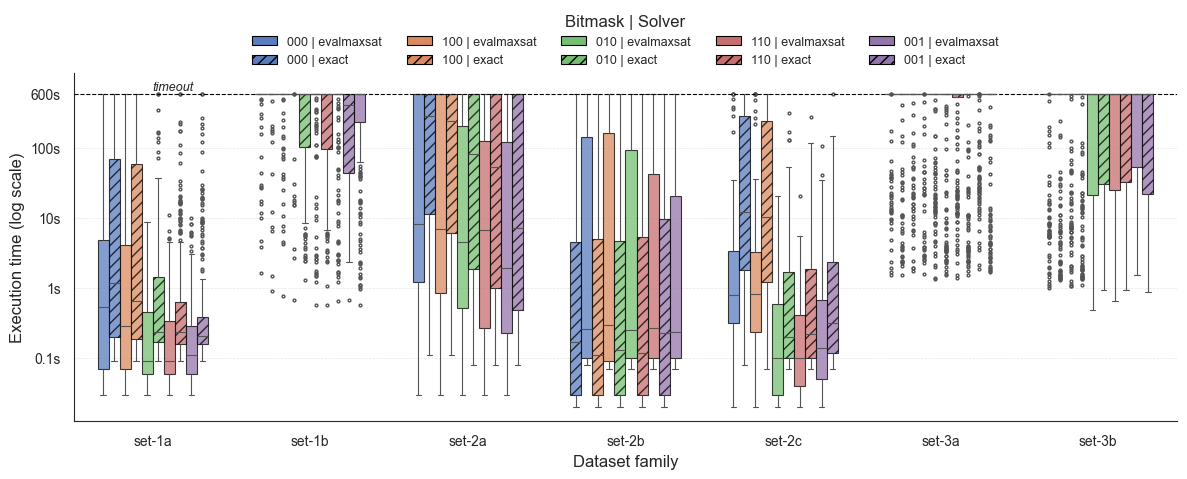

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import PathPatch

# --- 1. Style (paper-like) ---
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["STIXGeneral"],
        "mathtext.fontset": "stix",
        "font.size": 11,
        "axes.labelsize": 12,
        "legend.fontsize": 9,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.linewidth": 0.8,
    }
)

sns.set_style("white")

# --- 2. Data prep ---
show_df = df_wandb.copy()
implied_order = ["000", "100", "010", "110", "001"]
solvers_to_compare = ["evalmaxsat", "exact"]

show_df["implied_bitmask_str"] = show_df["implied_bitmask_short"].astype(str)
show_df["solver"] = show_df["solver"].astype(str).str.strip()
show_df["hue_group"] = show_df["implied_bitmask_str"] + " | " + show_df["solver"]

plot_df = show_df[show_df["solver"].isin(solvers_to_compare)].copy()
group_order = [f"{imp} | {sol}" for imp in implied_order for sol in solvers_to_compare]

# --- 3. Colors ---
base_colors = sns.color_palette("muted", len(implied_order))
palette = []
for c in base_colors:
    palette.extend([c, c])  # same color per bitmask

# --- 4. Plot ---
fig, ax = plt.subplots(figsize=(12, 5))

sns.boxplot(
    data=plot_df,
    x="family",
    y="solver.log_real_time",
    hue="hue_group",
    hue_order=group_order,
    order=family_order,
    palette=palette,
    linewidth=0.8,
    fliersize=2,
    width=0.7,
    boxprops={"edgecolor": "black"},
    ax=ax,
)

# --- 5. FIXED HATCHING (this is the key part) ---
boxes = [p for p in ax.patches if isinstance(p, PathPatch)]

for i, box in enumerate(boxes):
    if i % 2 == 1:  # exact solver
        box.set_hatch("///")
        box.set_edgecolor("black")
    box.set_alpha(0.75)  # helps hatch visibility

# --- 6. Axes ---
timeout_log = np.log10(600)
human_times = [0.1, 1, 10, 100, 600]

ax.set_ylim(plot_df["solver.log_real_time"].min() - 0.2, timeout_log + 0.3)

ax.axhline(timeout_log, color="black", linestyle="--", linewidth=0.8)
ax.text(0, timeout_log + 0.05, "timeout", fontsize=9, style="italic")

ax.set_yticks([np.log10(t) for t in human_times])
ax.set_yticklabels([f"{t:g}s" for t in human_times])

ax.set_xlabel("Dataset family")
ax.set_ylabel("Execution time (log scale)")

# --- 7. Legend ---
handles, labels = ax.get_legend_handles_labels()

leg = ax.legend(
    handles,
    labels,
    title="Bitmask | Solver",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.2),
    ncol=5,
    frameon=False,
)

# apply hatch to legend too
for i, patch in enumerate(leg.legend_handles):
    if i % 2 == 1:
        patch.set_hatch("///")

# --- 8. Final polish ---
sns.despine()
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig("solver_comparison.pdf", bbox_inches="tight")
plt.show()

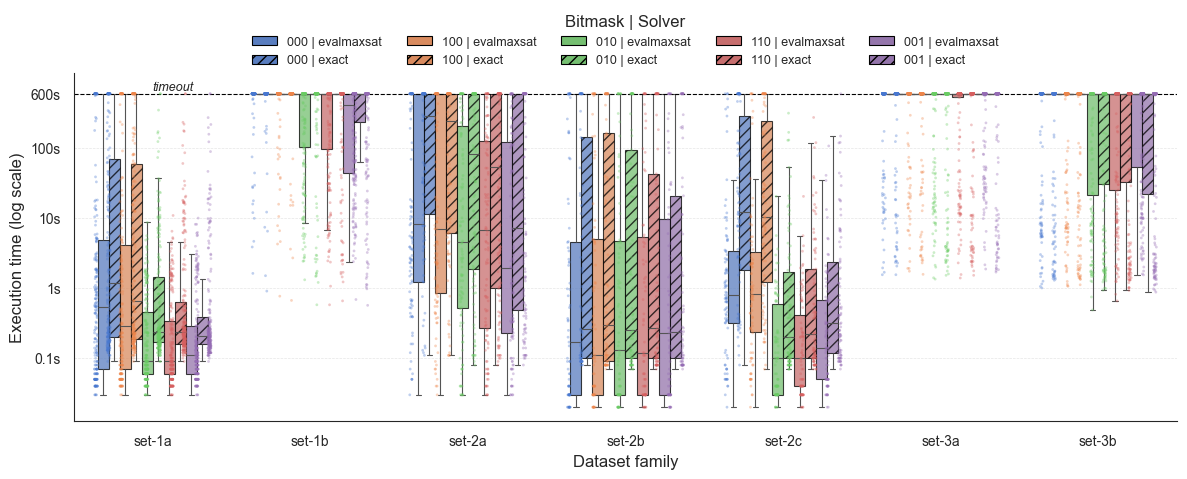

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import PathPatch

# --- 1. Style ---
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["STIXGeneral"],
        "mathtext.fontset": "stix",
        "font.size": 11,
        "axes.labelsize": 12,
        "legend.fontsize": 9,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.linewidth": 0.8,
    }
)

sns.set_style("white")

# --- 2. Data prep ---
show_df = df_wandb.copy()
implied_order = ["000", "100", "010", "110", "001"]
solvers_to_compare = ["evalmaxsat", "exact"]

show_df["implied_bitmask_str"] = show_df["implied_bitmask_short"].astype(str)
show_df["solver"] = show_df["solver"].astype(str).str.strip()
show_df["hue_group"] = show_df["implied_bitmask_str"] + " | " + show_df["solver"]

plot_df = show_df[show_df["solver"].isin(solvers_to_compare)].copy()
group_order = [f"{imp} | {sol}" for imp in implied_order for sol in solvers_to_compare]

# --- 3. Colors ---
base_colors = sns.color_palette("muted", len(implied_order))
palette = []
for c in base_colors:
    palette.extend([c, c])

# --- 4. Plot ---
fig, ax = plt.subplots(figsize=(12, 5))

# --- BOXPLOT ---
sns.boxplot(
    data=plot_df,
    x="family",
    y="solver.log_real_time",
    hue="hue_group",
    hue_order=group_order,
    order=family_order,
    palette=palette,
    linewidth=0.8,
    fliersize=0,  # keep clean, we'll show real points instead
    width=0.7,
    boxprops={"edgecolor": "black"},
    ax=ax,
)

# --- STRIPPLOT (actual data points) ---
sns.stripplot(
    data=plot_df,
    x="family",
    y="solver.log_real_time",
    hue="hue_group",
    hue_order=group_order,
    order=family_order,
    dodge=True,
    size=2,
    alpha=0.35,
    palette=palette,
    ax=ax,
)

# --- REMOVE duplicate legend from stripplot ---
ax.legend_.remove()

# --- 5. Hatching ---
boxes = [p for p in ax.patches if isinstance(p, PathPatch)]

num_families = len(plot_df["family"].unique())

for i, box in enumerate(boxes):
    # Determine which hue group this box belongs to
    hue_idx = i // num_families

    # Since 'exact' solvers are at odd indices in your group_order (1, 3, 5, 7, 9)
    if hue_idx % 2 == 1:
        box.set_hatch("///")
        box.set_edgecolor((0, 0, 0, 0.8))  # solid black edge for better visibility
    box.set_alpha(0.75)

# --- 6. Axes ---
timeout_log = np.log10(600)
human_times = [0.1, 1, 10, 100, 600]

ax.set_ylim(plot_df["solver.log_real_time"].min() - 0.2, timeout_log + 0.3)

ax.axhline(timeout_log, color="black", linestyle="--", linewidth=0.8)
ax.text(0, timeout_log + 0.05, "timeout", fontsize=9, style="italic")

ax.set_yticks([np.log10(t) for t in human_times])
ax.set_yticklabels([f"{t:g}s" for t in human_times])

ax.set_xlabel("Dataset family")
ax.set_ylabel("Execution time (log scale)")

# --- 7. Legend (rebuild clean one) ---
handles, labels = ax.get_legend_handles_labels()

# keep only first half (boxplot ones)
handles = handles[: len(group_order)]
labels = labels[: len(group_order)]

leg = ax.legend(
    handles,
    labels,
    title="Bitmask | Solver",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.2),
    ncol=5,
    frameon=False,
)

# apply hatch in legend
for i, patch in enumerate(leg.legend_handles):
    if i % 2 == 1:
        patch.set_hatch("///")

# --- 8. Final polish ---
sns.despine()
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig("solver_comparison.pdf", bbox_inches="tight")
plt.show()

In [80]:
num_families = len(plot_df["family"].unique())

for i, box in enumerate(boxes):
    # Determine which hue group this box belongs to
    hue_idx = i // num_families

    # Since 'exact' solvers are at odd indices in your group_order (1, 3, 5, 7, 9)
    if hue_idx % 2 == 1:

        box.set_hatch("///")
        box.set_edgecolor((0, 0, 0, 0.8))  # solid black edge for better visibility
    box.set_alpha(0.75)